Found 8 files:

rfd4 files:
  20260128_025331_rfd4tbs2.csv
  20260128_025331_rfd4tbs3.csv
  20260128_025331_rfd4tbs4.csv

rfd10 files:
  20260128_025331_rfd10tbs1.csv
  20260128_025331_rfd10tbs2.csv
  20260128_025331_rfd10tbs3.csv

rfd11 files:
  20260128_025331_rfd11tbs1.csv
  20260128_025331_rfd11tbs2.csv
20260128_025331_rfd4tbs2.csv: Original edge at -9.650 µs → Shifted by 15.307 µs → Target 5.657 µs
20260128_025331_rfd10tbs1.csv: Original edge at -10.475 µs → Shifted by 16.170 µs → Target 5.695 µs
20260128_025331_rfd11tbs1.csv: Original edge at -0.200 µs → Shifted by 6.395 µs → Target 6.195 µs
20260128_025331_rfd11tbs2.csv: Original edge at -0.200 µs → Shifted by 6.395 µs → Target 6.195 µs


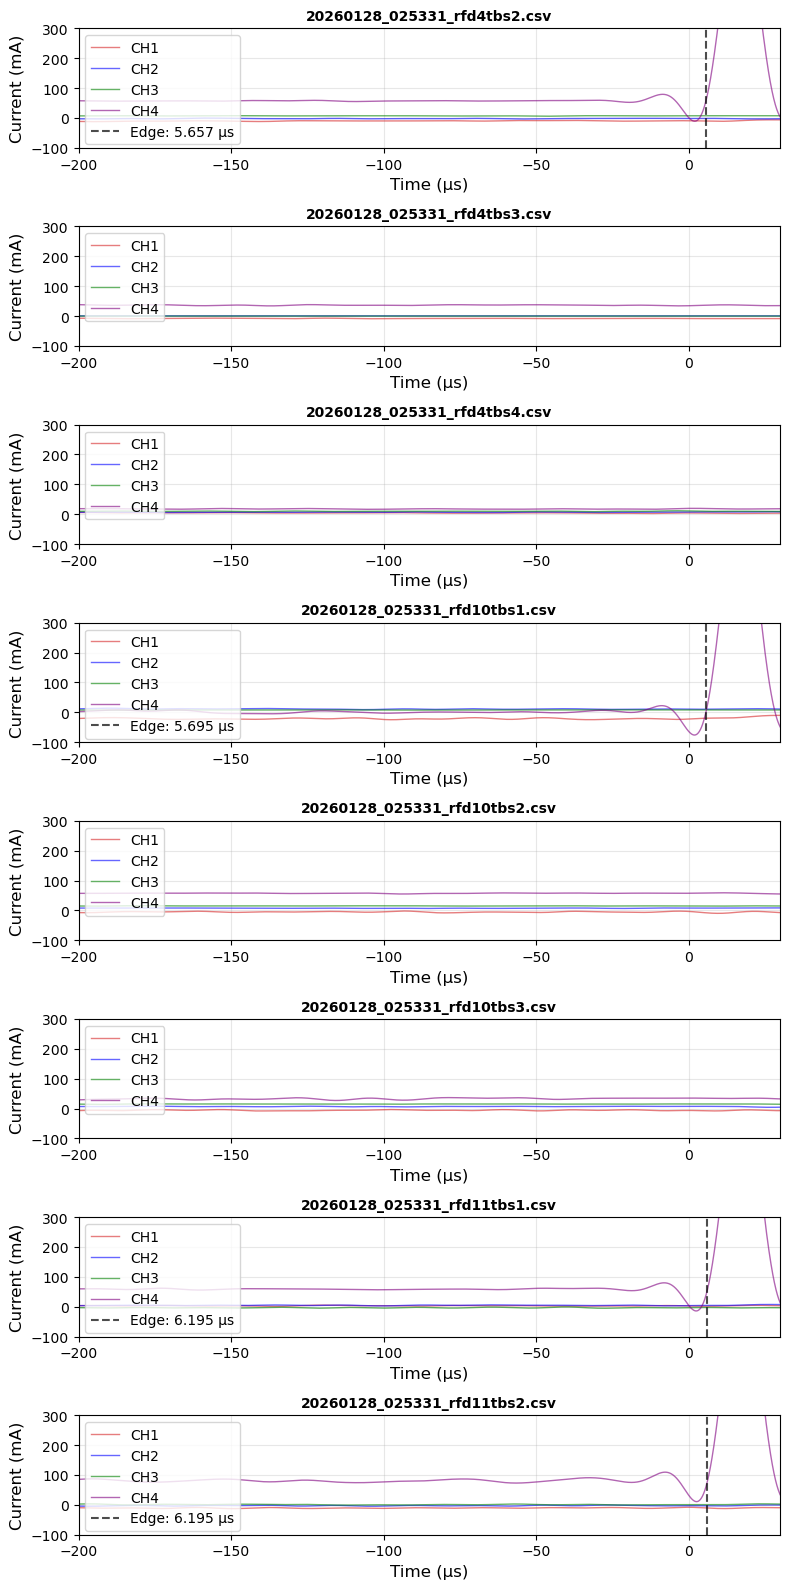

In [32]:
# Plot all electrode traces on the same figure
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import butter, filtfilt
from pathlib import Path

# ===== INPUT: Define date and time to search for =====
search_date = "20260128"  # Format: YYYYMMDD
search_time = "025331"    # Format: HHMMSS

# Data folder path
data_folder = Path("/Users/xylu/Desktop/Data/electrode_local")

# Automatically find files matching the date and time
search_pattern = f"{search_date}_{search_time}_*.csv"
all_files = sorted(data_folder.glob(search_pattern))

# Group files by RFD type and sort within groups
rfd4_files = sorted([f for f in all_files if 'rfd4' in f.name])
rfd10_files = sorted([f for f in all_files if 'rfd10' in f.name])
rfd11_files = sorted([f for f in all_files if 'rfd11' in f.name])

# Combine in order: rfd4, rfd10, rfd11
file_paths = rfd4_files + rfd10_files + rfd11_files

if not file_paths:
    print(f"No files found matching pattern: {search_pattern}")
else:
    print(f"Found {len(file_paths)} files:")
    print("\nrfd4 files:")
    for f in rfd4_files:
        print(f"  {f.name}")
    print("\nrfd10 files:")
    for f in rfd10_files:
        print(f"  {f.name}")
    print("\nrfd11 files:")
    for f in rfd11_files:
        print(f"  {f.name}")

# Filter settings
enable_filter = True
cutoff_freq = 50e3  # Hz
filter_order = 4
sampling_rate = 1 / (75e-9)
nyquist = sampling_rate / 2

# Edge detection settings
high_threshold_ma = 150  # mA - detect major rise
baseline_window_us = (-100, -50)  # Time window for baseline calculation

# Target edge times for time alignment
target_edge_times = {
    'rfd4tbs2': 5.657,
    'rfd10tbs1': 5.695,
    'rfd11tbs1': 6.195,
    'rfd11tbs2': 6.195
}

fig, axes = plt.subplots(8, 1, figsize=(8, 16))
axes = axes.flatten()

# Channel colors
color_map = {'CH1': '#d62728', 'CH2': 'blue', 'CH3': 'green', 'CH4': 'purple'}

# Plot each file
for idx, file_path in enumerate(file_paths):
    if idx >= len(axes):
        break
    
    title_name = os.path.basename(file_path)
    
    # Read all channels for all files
    df = pd.read_csv(file_path, skiprows=4, usecols=['CH1', 'CH2', 'CH3', 'CH4'])
    channels = ['CH1', 'CH2', 'CH3', 'CH4']
    
    time_us = np.arange(len(df)) * 75e-9*1e6 - 1400
    
    # Detect rising edge for CH4 before plotting
    ch4_data = df['CH4'].values.copy()
    if enable_filter and cutoff_freq:
        normalized_cutoff = cutoff_freq / nyquist
        if 0 < normalized_cutoff < 1:
            b, a = butter(filter_order, normalized_cutoff, btype='low')
            ch4_data_filt = filtfilt(b, a, ch4_data)
    else:
        ch4_data_filt = ch4_data
    
    current_ch4_ma = ch4_data_filt / 50 * 1000
    
    # Calculate baseline
    baseline_mask = (time_us >= baseline_window_us[0]) & (time_us <= baseline_window_us[1])
    baseline_current = current_ch4_ma[baseline_mask].mean()
    
    # Find rising edge
    above_high = current_ch4_ma > high_threshold_ma
    high_indices = np.where(above_high)[0]
    rising_edge_time = None
    
    if len(high_indices) > 0:
        high_idx = high_indices[0]
        edge_idx = high_idx
        for i in range(high_idx, -1, -1):
            if current_ch4_ma[i] < baseline_current:
                edge_idx = i
                break
        rising_edge_time = time_us[edge_idx]
    
    # Apply time shift to align edge to target time
    # Extract file identifier (e.g., 'rfd4tbs2' from filename)
    file_stem = file_path.stem  # e.g., '20260128_025331_rfd4tbs2'
    file_id = file_stem.split('_')[-1]  # e.g., 'rfd4tbs2'
    
    if file_id in target_edge_times and rising_edge_time is not None:
        target_time = target_edge_times[file_id]
        time_shift = target_time - rising_edge_time
        print(f"{title_name}: Original edge at {rising_edge_time:.3f} µs → Shifted by {time_shift:.3f} µs → Target {target_time:.3f} µs")
        time_us = time_us + time_shift
        rising_edge_time = target_time  # Update to target time
    
    # Plot each channel
    for ch_name in channels:
        ch_data = df[ch_name].values
        
        # Apply filter
        if enable_filter and cutoff_freq:
            normalized_cutoff = cutoff_freq / nyquist
            if 0 < normalized_cutoff < 1:
                b, a = butter(filter_order, normalized_cutoff, btype='low')
                ch_data = filtfilt(b, a, ch_data)
        
        # Convert to current in mA
        current_ma = ch_data / 50 * 1000
        
        # Plot with label and color for all channels
        axes[idx].plot(time_us, current_ma, color=color_map[ch_name], linewidth=1, 
                      marker=None, markersize=1, alpha=0.6, label=ch_name)
    
    # Add rising edge marker if detected
    if rising_edge_time is not None:
        axes[idx].axvline(x=rising_edge_time, color='black', linestyle='--', linewidth=1.5, 
                         alpha=0.7, label=f'Edge: {rising_edge_time:.3f} µs')
    
    axes[idx].set_xlabel('Time (µs)', fontsize=12)
    axes[idx].set_ylabel('Current (mA)', fontsize=12)
    axes[idx].set_title(title_name, fontsize=10, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(labelsize=10)
    axes[idx].set_ylim(-100, 300)
    axes[idx].set_xlim(-200, 30)
    axes[idx].legend(fontsize=10, loc='upper left')

# Hide unused subplots
for idx in range(len(file_paths), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


Rising Edge Detection (CH4)
Method: Find first crossing of 150 mA, then backtrack to baseline
Baseline = average CH4 from -100 to -50 µs

20260128_025331_rfd4tbs2.csv:
  Baseline: 57.62 mA
  First crossing 150 mA at: -7.78 µs
  → Rising edge (baseline) at: -9.65 µs
  Current at edge: 54.72 mA

20260128_025331_rfd10tbs1.csv:
  Baseline: 0.41 mA
  First crossing 150 mA at: -7.92 µs
  → Rising edge (baseline) at: -10.48 µs
  Current at edge: -0.38 mA

20260128_025331_rfd11tbs1.csv:
  Baseline: 58.99 mA
  First crossing 150 mA at: 1.60 µs
  → Rising edge (baseline) at: -0.20 µs
  Current at edge: 56.68 mA

20260128_025331_rfd11tbs2.csv:
  Baseline: 80.11 mA
  First crossing 150 mA at: 1.22 µs
  → Rising edge (baseline) at: -0.20 µs
  Current at edge: 78.84 mA


In [ ]:
Rising Edge Detection (CH4 > 150 mA)
============================================================

20260128_025331_rfd4tbs2.csv:
  Rising edge at: -7.78 µs
  Current at edge: 150.92 mA

20260128_025331_rfd10tbs1.csv:
  Rising edge at: -7.92 µs
  Current at edge: 154.86 mA

20260128_025331_rfd11tbs1.csv:
  Rising edge at: 1.60 µs
  Current at edge: 153.73 mA

20260128_025331_rfd11tbs2.csv:
  Rising edge at: 1.22 µs
  Current at edge: 151.90 mA

Found 8 files:

rfd4 files:
  20260128_025331_rfd4tbs2.csv
  20260128_025331_rfd4tbs3.csv
  20260128_025331_rfd4tbs4.csv

rfd10 files:
  20260128_025331_rfd10tbs1.csv
  20260128_025331_rfd10tbs2.csv
  20260128_025331_rfd10tbs3.csv

rfd11 files:
  20260128_025331_rfd11tbs1.csv
  20260128_025331_rfd11tbs2.csv


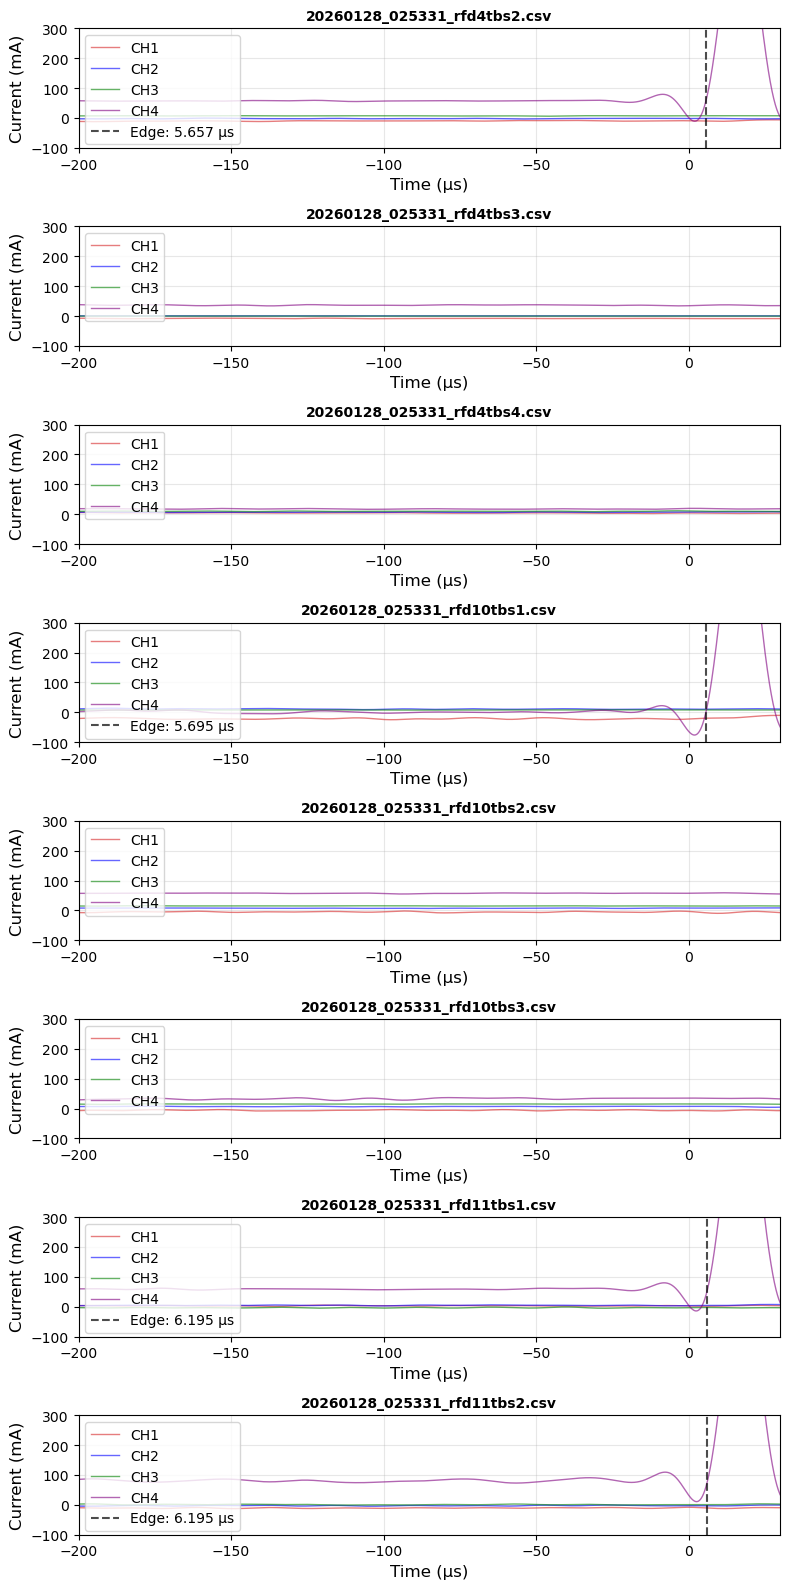

In [33]:
## Check: shifted
# Plot electrode traces with pre-calculated time shifts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import butter, filtfilt
from pathlib import Path

# ===== INPUT: Define date and time to search for =====
search_date = "20260128"  # Format: YYYYMMDD
search_time = "025331"    # Format: HHMMSS

# Data folder path
data_folder = Path("/Users/xylu/Desktop/Data/electrode_local")

# Automatically find files matching the date and time
search_pattern = f"{search_date}_{search_time}_*.csv"
all_files = sorted(data_folder.glob(search_pattern))

# Group files by RFD type and sort within groups
rfd4_files = sorted([f for f in all_files if 'rfd4' in f.name])
rfd10_files = sorted([f for f in all_files if 'rfd10' in f.name])
rfd11_files = sorted([f for f in all_files if 'rfd11' in f.name])

# Combine in order: rfd4, rfd10, rfd11
file_paths = rfd4_files + rfd10_files + rfd11_files

if not file_paths:
    print(f"No files found matching pattern: {search_pattern}")
else:
    print(f"Found {len(file_paths)} files:")
    print("\nrfd4 files:")
    for f in rfd4_files:
        print(f"  {f.name}")
    print("\nrfd10 files:")
    for f in rfd10_files:
        print(f"  {f.name}")
    print("\nrfd11 files:")
    for f in rfd11_files:
        print(f"  {f.name}")

# Filter settings
enable_filter = True
cutoff_freq = 50e3  # Hz
filter_order = 4
sampling_rate = 1 / (75e-9)
nyquist = sampling_rate / 2

# Pre-calculated time shifts for each file type (in µs)
# These shifts align the rising edge to the target times
time_shifts = {
    'rfd4tbs2': 15.307,     # Shifts edge from -9.650 to 5.657 µs
    'rfd10tbs1': 16.170,    # Shifts edge from -10.475 to 5.695 µs
    'rfd11tbs1': 6.395,     # Shifts edge from -0.200 to 6.195 µs
    'rfd11tbs2': 6.395      # Shifts edge from -0.200 to 6.195 µs
}

# Target edge times (for display in legend)
target_edge_times = {
    'rfd4tbs2': 5.657,
    'rfd10tbs1': 5.695,
    'rfd11tbs1': 6.195,
    'rfd11tbs2': 6.195
}

# Create subplots based on number of files found
num_files = len(file_paths)
if num_files > 0:
    fig, axes = plt.subplots(num_files, 1, figsize=(8, 2 * num_files))
    if num_files == 1:
        axes = [axes]  # Make it iterable for single subplot
else:
    print("No files to plot")
    exit()

# Channel colors
color_map = {'CH1': '#d62728', 'CH2': 'blue', 'CH3': 'green', 'CH4': 'purple'}

# Plot each file
for idx, file_path in enumerate(file_paths):
    
    title_name = os.path.basename(file_path)
    
    # Read all channels
    df = pd.read_csv(file_path, skiprows=4, usecols=['CH1', 'CH2', 'CH3', 'CH4'])
    channels = ['CH1', 'CH2', 'CH3', 'CH4']
    
    # Create time array with base offset
    time_us = np.arange(len(df)) * 75e-9 * 1e6 - 1400
    
    # Extract file identifier (e.g., 'rfd4tbs2' from filename)
    file_stem = file_path.stem  # e.g., '20260128_025331_rfd4tbs2'
    file_id = file_stem.split('_')[-1]  # e.g., 'rfd4tbs2'
    
    # Apply pre-calculated time shift
    if file_id in time_shifts:
        time_us = time_us + time_shifts[file_id]
        edge_time = target_edge_times.get(file_id)
    else:
        edge_time = None
    
    # Plot each channel
    for ch_name in channels:
        ch_data = df[ch_name].values
        
        # Apply filter
        if enable_filter and cutoff_freq:
            normalized_cutoff = cutoff_freq / nyquist
            if 0 < normalized_cutoff < 1:
                b, a = butter(filter_order, normalized_cutoff, btype='low')
                ch_data = filtfilt(b, a, ch_data)
        
        # Convert to current in mA
        current_ma = ch_data / 50 * 1000
        
        # Plot with label and color
        axes[idx].plot(time_us, current_ma, color=color_map[ch_name], linewidth=1, 
                      marker=None, markersize=1, alpha=0.6, label=ch_name)
    
    # Add rising edge marker if available
    if edge_time is not None:
        axes[idx].axvline(x=edge_time, color='black', linestyle='--', linewidth=1.5, 
                         alpha=0.7, label=f'Edge: {edge_time:.3f} µs')
    
    axes[idx].set_xlabel('Time (µs)', fontsize=12)
    axes[idx].set_ylabel('Current (mA)', fontsize=12)
    axes[idx].set_title(title_name, fontsize=10, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(labelsize=10)
    axes[idx].set_ylim(-100, 300)
    axes[idx].set_xlim(-200, 30)
    axes[idx].legend(fontsize=10, loc='upper left')

# Hide unused subplots
for idx in range(len(file_paths), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [3]:
# # TEST CELL
# # Compare different cutoff frequencies in low pass filter
# # Using pre-loaded df and time_us from Cell 1

# # Filter settings
# filter_order = 4  # Reverted to earlier, gentler slope
# cutoff_frequencies = [500e3, 200e3]  # Hz - previous higher cutoffs

# # Compute shared y-limits
# y_min = df['CH1'].min()
# y_max = df['CH1'].max()
# y_margin = (y_max - y_min) * 0.05
# y_min -= y_margin
# y_max += y_margin

# # Define shared x-limits
# xlim = (0.7, 0.8)

# # Create two subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# # Left: Unfiltered
# ax1.plot(time_us, df['CH1'], color='black', linewidth=1, marker='o', markersize=4, alpha=0.6)
# ax1.set_xlabel('Time (µs)', fontsize=16)
# ax1.set_ylabel('Voltage (V)', fontsize=16)
# ax1.set_title('Unfiltered', fontsize=16, fontweight='bold')
# ax1.set_xlim(xlim)
# ax1.set_ylim(y_min, y_max)
# ax1.grid(True, alpha=0.3)
# ax1.tick_params(labelsize=14)

# # Right: Plot filtered with different cutoff frequencies
# sampling_rate = 1 / (75e-9)
# nyquist = sampling_rate / 2

# if nyquist > 0:
#     colors = ['#d62728', 'orange', 'green', 'purple']
#     for cutoff, color in zip(cutoff_frequencies, colors):
#         normalized_cutoff = cutoff / nyquist
#         if 0 < normalized_cutoff < 1:
#             b, a = butter(filter_order, normalized_cutoff, btype='low')
#             df_filt = filtfilt(b, a, df['CH1'])
#             ax2.plot(time_us, df_filt, label=f'{cutoff/1e3:.0f} kHz', color=color, linewidth=1, marker='o', markersize=4, alpha=0.6)

# ax2.set_xlabel('Time (µs)', fontsize=16)
# ax2.set_ylabel('Voltage (V)', fontsize=16)
# ax2.set_title(f'Filtered Cutoff Frequencies (Order: {filter_order})', fontsize=16, fontweight='bold')
# ax2.set_xlim(xlim)
# ax2.set_ylim(y_min, y_max)
# ax2.legend(fontsize=14, loc='upper right')
# ax2.grid(True, alpha=0.3)
# ax2.tick_params(labelsize=14)

# plt.tight_layout()
# plt.show()

In [2]:
# # TEST CELL
# # Compare CH1 traces and FFTs for two files
# # Top: time-domain overlay; Bottom: FFT overlay (windowed 600–1000 ns)

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# # Sampling
# dt = 75e-9  # 75 ns
# fs = 1.0 / dt

# file_a = Path("/Users/xylu/Desktop/Data/electrode/20260126_172813_rfd10tbs2.csv")
# file_b = Path("/Users/xylu/Desktop/Data/electrode/20260126_151216_rfd10tbs2.csv")

# # Time window in ns (applied to FFT segment)
# t_window_ns = (600, 1000)
# t_start_us = t_window_ns[0] / 1000.0
# t_end_us = t_window_ns[1] / 1000.0


# def load_ch1(path: Path):
#     df_local = pd.read_csv(path, skiprows=4, usecols=["CH1"])  
#     x = df_local["CH1"].to_numpy(dtype=float)
#     t_us = np.arange(x.size) * 75e-6
#     return t_us, x


# def compute_fft(x: np.ndarray):
#     N = x.size
#     x = x - np.mean(x)
#     window = np.hanning(N)
#     xw = x * window
#     X = np.fft.rfft(xw)
#     freqs = np.fft.rfftfreq(N, d=dt)
#     coherent_gain = np.sum(window) / N
#     amplitude = (2.0 / N) * np.abs(X) / coherent_gain
#     return freqs, amplitude

# # Load signals
# t_a, x_a = load_ch1(file_a)
# t_b, x_b = load_ch1(file_b)

# # Masks for windowed FFT
# mask_a = (t_a >= t_start_us) & (t_a <= t_end_us)
# mask_b = (t_b >= t_start_us) & (t_b <= t_end_us)

# # Windowed segments for FFT
# x_a_win = x_a[mask_a]
# x_b_win = x_b[mask_b]

# # Compute FFTs on windowed segments
# f_a, A_a = compute_fft(x_a_win)
# f_b, A_b = compute_fft(x_b_win)

# fig, (ax_t, ax_f) = plt.subplots(2, 1, figsize=(14, 8))

# # Top: time-domain traces (full, with optional zoom)
# ax_t.plot(t_a, x_a, label=file_a.name, color="#d62728", linewidth=1)
# ax_t.plot(t_b, x_b, label=file_b.name, color="blue", linewidth=1)
# ax_t.set_xlabel("Time (µs)", fontsize=16)
# ax_t.set_ylabel("Voltage (V)", fontsize=16)
# ax_t.set_title("Trace Comparison - CH1", fontsize=16, fontweight="bold")
# ax_t.grid(True, alpha=0.3)
# ax_t.legend(fontsize=12, loc="upper right")
# ax_t.tick_params(labelsize=14)

# # Optional zoom for time-domain
# xlim_us = (t_start_us, t_end_us)  # focus on the same window
# if xlim_us:
#     ax_t.set_xlim(xlim_us)

# # Bottom: FFT overlay (windowed)
# ax_f.plot(f_a / 1e6, A_a, label=f"{file_a.name} (FFT {t_window_ns[0]}–{t_window_ns[1]} ns)", color="#d62728", linewidth=1)
# ax_f.plot(f_b / 1e6, A_b, label=f"{file_b.name} (FFT {t_window_ns[0]}–{t_window_ns[1]} ns)", color="blue", linewidth=1)
# ax_f.set_xlabel("Frequency (MHz)", fontsize=16)
# ax_f.set_ylabel("Amplitude (V)", fontsize=16)
# ax_f.set_title("FFT Comparison - CH1 (Window: 600–1000 ns)", fontsize=16, fontweight="bold")
# ax_f.grid(True, alpha=0.3)
# ax_f.legend(fontsize=12, loc="upper right")
# ax_f.tick_params(labelsize=14)
# # ax_f.set_xlim(0,1)

# # Optional zoom for frequency domain
# freq_max_mhz = None
# if freq_max_mhz:
#     ax_f.set_xlim(0, freq_max_mhz)

# plt.tight_layout()
# plt.show()